In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
def calc_total_variation(p, q):
    p=np.array(p)
    q=np.array(q)
    return 0.5* np.sum(np.abs(p-q))

In [34]:
def compute_one(input_data):   
    # print(np.array(input_data).shape)
    data = input_data
    # convert the list of lists into a full list 
    # for lst in input_data:
    #     print(lst)
    #     data.extend(list(lst))

    num_bootstraps = 1000

    def compute_statistic(sample):
        # todo: weighted average so that nytimes is weighted 50% and opinionqa is weighted 50%
        return np.mean(sample)  

    # Bootstrapping process
    bootstrap_statistics = []
    for _ in range(num_bootstraps):
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        statistic = compute_statistic(bootstrap_sample)
        bootstrap_statistics.append(statistic)

    # 95% confidence interval
    confidence_level = 0.95
    alpha = (1 - confidence_level) / 2
    lower_percentile = alpha * 100
    upper_percentile = (1 - alpha) * 100
    lower_bound = np.percentile(bootstrap_statistics, lower_percentile)
    upper_bound = np.percentile(bootstrap_statistics, upper_percentile)
    
    return np.mean(bootstrap_statistics), (upper_bound-lower_bound)/2

def normalize(array):
  total_sum = np.sum(array)
  normalized_array = array / total_sum
  return normalized_array

def compute_tv_human_annotations(df, nosteer=True, k=4, ingroup=False, outgroup=False, ingroup_name = 'Democrat'):
  if ingroup: print('in group')
  if outgroup: print('out group')
  dem_group_to_dem_mapping = {
                              'POLPARTY': ['Democrat', 'Republican'],
                              'SEX': ['Male', 'Female']
                              }

  data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NONE_data.json'
  with open(data_path, 'r') as json_file:
    # Load JSON data
    data = json.load(json_file)

  dem_to_qualtrics_map = {'Democrat': 'Q_NoSteering', 'Republican': 'Q135', 'Male':'Q136', 'Female': 'Q137'}
  dem_to_demgroup = {'Democrat': 'POLPARTY', 'Republican': 'POLPARTY', 'Male':'SEX', 'Female': 'SEX'}

  tv_across_groups, hv_across_groups, expected_across_groups = [], [], []

  if ingroup: 
    list_of_groups = [ingroup_name]
  elif outgroup:
    list_of_groups = dem_group_to_dem_mapping[dem_to_demgroup[ingroup_name]].copy()
    list_of_groups.remove(ingroup_name)
  else: list_of_groups = list(dem_to_demgroup.keys())
  # print(ingroup_name, list_of_groups)

  for dem in list_of_groups:
    num_responses, all_tvs = [], []
    for qID in list(data.keys()):
      qualtricsID = qID_to_qualtricsID[qID]
      cols = []
      if nosteer: qualtrics_str = 'Q_NoSteering'
      else: 
        qualtrics_str = dem_to_qualtrics_map[dem]
      cols.append(str(qualtricsID)+'_{}_1'.format(qualtrics_str))
      cols.append(str(qualtricsID)+'_{}_2'.format(qualtrics_str))
      cols.append(str(qualtricsID)+'_{}_3'.format(qualtrics_str))
      cols.append(str(qualtricsID)+'_{}_4'.format(qualtrics_str))

      df_cleaned = df[cols].dropna()[:k]
      num_responses.append(len(df_cleaned))
      if len(df_cleaned)>0: 
        expected_results_str = '{}'.format(dem)
        MC_options = list(data[qID][expected_results_str].keys())
        human_values = np.mean(np.array(df_cleaned, dtype=np.float64), axis=0)[:len(MC_options)] * 0.01
        human_results = dict(zip(MC_options, human_values))

        gt_results = normalize(np.array(list(data[qID][expected_results_str].values())))
        # print(human_values, gt_results)
        tv = calc_total_variation(human_values, gt_results)
        all_tvs.append(tv)
        hv_across_groups.append(human_values)
        expected_across_groups.append(gt_results)
    tv_across_groups.extend(all_tvs)
    mean, bs = compute_one(all_tvs)
    print("{}: {:.3f} +/- {:.3f}".format(dem, mean, bs))
    
    # print(len(all_tvs))
  mean, bs = compute_one(tv_across_groups)
  return mean, bs, tv_across_groups, num_responses# , hv_across_groups, expected_across_groups

#### NYT Human Distributional Alignment Task: No steer

In [35]:
nosteer_df_1 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/Distributional_Alignment_No_Steering - NYT_July 1, 2024_12.41.csv')
nosteer_df_1 = nosteer_df_1.drop(index=[0, 1])

nosteer_df_2 = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/Distributional_Alignment_No_Steering - NYT - V2_July 2, 2024_18.52.csv')
nosteer_df_2 = nosteer_df_2.drop(index=[0, 1])

nosteer_df =  pd.concat([nosteer_df_1, nosteer_df_2])


In [36]:
# col_to_del = ['StartDate',	'EndDate',	'Status',	'IPAddress',	'Progress',	'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'QDem_Race_6_TEXT', 'Q_DemRepub_6_TEXT',
#               'Q133_1',  'Q133_2', 'Q136']

col_to_keep = ['QDem_Age', 'QDem_Gend', 'QDem_Race', 'Q_DemRepub', 'QDem_Income'] # demographics

# delete the first two rows

In [37]:
data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NONE_data.json'
with open(data_path, 'r') as json_file:
    # Load JSON data
    data = json.load(json_file)

In [38]:
qualtricsID_to_qID, qID_to_qualtricsID = {}, {}
for i, qualtricsID in enumerate([1] + list(np.arange(103, 337))):
  col_to_keep.append(str(qualtricsID)+'_Q138')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_1')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_2')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_3')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_4')
  qualtricsID_to_qID[qualtricsID] = list(data.keys())[i]
  qID_to_qualtricsID[list(data.keys())[i]] = qualtricsID

In [39]:
mean, bs, tv_across_groups, num_responses = compute_tv_human_annotations(nosteer_df, nosteer=True, k=4, ingroup=False, outgroup=False, ingroup_name = 'Democrat')

Democrat: 0.221 +/- 0.012
Republican: 0.213 +/- 0.012
Male: 0.227 +/- 0.013
Female: 0.210 +/- 0.011


In [40]:
print(mean, bs)

0.2177632897175955 0.0057814766955623376


In [41]:
for i, n_rep in enumerate(num_responses):
    if n_rep<4: print(list(data.keys())[i], n_rep)

Locking Up Our Own By James Forman Jr 3


#### NYT Human Distributional Alignment Task: Persona Steer

In [42]:
persona_df = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/Distributional_Alignment_Persona_Steering - NYT_July 3, 2024_10.32.csv')
persona_df = persona_df.drop(index=[0, 1])

# col_to_del = ['StartDate',	'EndDate',	'Status',	'IPAddress',	'Progress',	'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'QDem_Race_6_TEXT', 'Q_DemRepub_6_TEXT',
#               'Q133_1',  'Q133_2', 'Q136']

col_to_keep = ['QDem_Age', 'QDem_Gend', 'QDem_Race', 'Q_DemRepub', 'QDem_Income'] # demographics

# delete the first two rows
data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NONE_data.json'
with open(data_path, 'r') as json_file:
    # Load JSON data
    data = json.load(json_file)
qualtricsID_to_qID, qID_to_qualtricsID = {}, {}
for i, qualtricsID in enumerate([1] + list(np.arange(103, 337))):
  col_to_keep.append(str(qualtricsID)+'_Q138')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_1')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_2')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_3')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_4')
  qualtricsID_to_qID[qualtricsID] = list(data.keys())[i]
  qID_to_qualtricsID[list(data.keys())[i]] = qualtricsID

mean, bs, tv_across_groups, num_responses = compute_tv_human_annotations(persona_df, nosteer=False, k=4, ingroup=False, outgroup=False, ingroup_name = 'Democrat')


Democrat: 0.272 +/- 0.014
Republican: 0.237 +/- 0.014
Male: 0.242 +/- 0.013
Female: 0.253 +/- 0.016
0


In [43]:
np.unique(persona_df.Q87, return_counts=True)

(array(['By analyzing the air that was trapped in the ice',
        'By analyzing the micro structure of the ice',
        'By examing micro-organisms that were trapped in the ice',
        'By examining the minerals contained in the ice'], dtype=object),
 array([99,  1,  3,  3]))

#### NYT Human Distributional Alignment Task: Few Shot Steer

In [44]:
fewshot_df = pd.read_csv('/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/Distributional_Alignment_FewShot_Steering - NYT_July 17, 2024_10.52.csv')
fewshot_df = fewshot_df.drop(index=[0, 1])

# col_to_del = ['StartDate',	'EndDate',	'Status',	'IPAddress',	'Progress',	'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId', 'RecipientLastName', 'QDem_Race_6_TEXT', 'Q_DemRepub_6_TEXT',
#               'Q133_1',  'Q133_2', 'Q136']

col_to_keep = ['QDem_Age', 'QDem_Gend', 'QDem_Race', 'Q_DemRepub', 'QDem_Income'] # demographics

# delete the first two rows
data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NONE_data.json'
with open(data_path, 'r') as json_file:
    # Load JSON data
    data = json.load(json_file)
qualtricsID_to_qID, qID_to_qualtricsID = {}, {}
for i, qualtricsID in enumerate([1] + list(np.arange(103, 337))):
  col_to_keep.append(str(qualtricsID)+'_Q138')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_1')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_2')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_3')
  col_to_keep.append(str(qualtricsID)+'_Q_NoSteering_4')
  qualtricsID_to_qID[qualtricsID] = list(data.keys())[i]
  qID_to_qualtricsID[list(data.keys())[i]] = qualtricsID

mean, bs, tv_across_groups, num_responses = compute_tv_human_annotations(fewshot_df, nosteer=False, k=4, ingroup=False, outgroup=False, ingroup_name = 'Democrat')
count=0


/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/4115090654.py:1: DtypeWarning: Columns (4,5,6,9,10,11,12,13,14,17,20,23,25,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,254,255,256,257,258,259,260,261,262,

Democrat: 0.221 +/- 0.012
Republican: 0.217 +/- 0.012
Male: 0.228 +/- 0.014
Female: 0.203 +/- 0.012
A Manual For Cleaning Women Lucia Berlin. Edited By Stephen Emerson 3
Gilead By Marilynne Robinson 3
John Henry Days By Colson Whitehead 3
Being Dead By Jim Crace 3
4


### Storing the data

In [45]:
nosteer, persona, fewshot= [], [], []
nosteer_mean, nosteer_bs, nosteer_data, _ = compute_tv_human_annotations(nosteer_df, nosteer=True, ingroup=False, outgroup=False)
persona_mean, persona_bs, persona_data, _ = compute_tv_human_annotations(persona_df, nosteer=False, ingroup=False, outgroup=False)
fewshot_mean, fewshot_bs, fewshot_data, _ = compute_tv_human_annotations(fewshot_df, nosteer=False, ingroup=False, outgroup=False)

print("No Steer: {:4f} +/- {:4f}".format(nosteer_mean, nosteer_bs))
print("Persona: {:4f} +/- {:4f}".format(persona_mean, persona_bs))
print("Few Shot: {:4f} +/- {:4f}".format(fewshot_mean, fewshot_bs))

human_annotation_data = {'nosteer': nosteer_data, 'persona': persona_data, 'fewshot': fewshot_data}

import json

# Specify the file name
filename = '/Users/nicolemeister/Desktop/STANFORD/distributions/results/human_annotations/NYT_human_tv_data.json'

# Writing to a JSON file
with open(filename, 'w') as file:
    json.dump(human_annotation_data, file, indent=4)

Democrat: 0.221 +/- 0.012
Republican: 0.213 +/- 0.012
Male: 0.226 +/- 0.014
Female: 0.210 +/- 0.011
Democrat: 0.273 +/- 0.015
Republican: 0.236 +/- 0.013
Male: 0.242 +/- 0.014
Female: 0.254 +/- 0.015
Democrat: 0.221 +/- 0.012
Republican: 0.216 +/- 0.011
Male: 0.228 +/- 0.014
Female: 0.204 +/- 0.011
No Steer: 0.217521 +/- 0.005713
Persona: 0.251039 +/- 0.007506
Few Shot: 0.217425 +/- 0.006349


#### In vs Out Group

In [46]:
# def compute_one(input_data):   
#     # print(np.array(input_data).shape)
#     data = input_data
#     # convert the list of lists into a full list 
#     # for lst in input_data:
#     #     print(lst)
#     #     data.extend(list(lst))

#     num_bootstraps = 1000

#     def compute_statistic(sample):
#         # todo: weighted average so that nytimes is weighted 50% and opinionqa is weighted 50%
#         return np.mean(sample)  

#     # Bootstrapping process
#     bootstrap_statistics = []
#     for _ in range(num_bootstraps):
#         bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
#         statistic = compute_statistic(bootstrap_sample)
#         bootstrap_statistics.append(statistic)

#     # 95% confidence interval
#     confidence_level = 0.95
#     alpha = (1 - confidence_level) / 2
#     lower_percentile = alpha * 100
#     upper_percentile = (1 - alpha) * 100
#     lower_bound = np.percentile(bootstrap_statistics, lower_percentile)
#     upper_bound = np.percentile(bootstrap_statistics, upper_percentile)
    
#     return np.mean(bootstrap_statistics), (upper_bound-lower_bound)/2

# def compute_tv_human_annotations(df, nosteer=True, k=4, ingroup=False, outgroup=False, ingroup_name = 'Democrat'):
#   dem_group_to_dem_mapping = {
#                               'POLPARTY': ['Democrat', 'Republican'],
#                               'SEX': ['Male', 'Female'],
#                               'RACE': ['Black', 'White']
#                               }

#   data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/gpt-3.5-turbo-0125/task0/Pew_American_Trends_Panel_disagreement_100/NONE/Democrat.json'
#   with open(data_path, 'r') as json_file:
#     # Load JSON data
#     data = json.load(json_file)

#   dem_to_qualtrics_map = {'Democrat': 'Q_NoSteering', 'Republican': 'Q135', 'Male':'Q136', 'Female': 'Q137', 'Black': 'Q138', 'White': 'Q139'}
#   dem_to_demgroup = {'Democrat': 'POLPARTY', 'Republican': 'POLPARTY', 'Male':'SEX', 'Female': 'SEX', 'Black': 'RACE', 'White': 'RACE'}

#   tv_across_groups, hv_across_groups, expected_across_groups = [], [], []

#   if ingroup: 
#     list_of_groups = [ingroup_name]
#   elif outgroup:
#     list_of_groups = dem_group_to_dem_mapping[dem_to_demgroup[ingroup_name]].copy()
#     list_of_groups.remove(ingroup_name)
#   else: list_of_groups = list(dem_to_demgroup.keys())
#   # print(ingroup_name, list_of_groups)

#   for dem in list_of_groups:
#     num_responses, all_tvs = [], []
#     for qID in list(data.keys()):
#       qualtricsID = qID_to_qualtricsID[qID]
#       cols = []
#       if nosteer: qualtrics_str = 'Q_NoSteering'
#       else: 
#         qualtrics_str = dem_to_qualtrics_map[dem]
#       cols.append(str(qualtricsID)+'_{}_1'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_2'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_3'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_4'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_5'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_6'.format(qualtrics_str))
#       cols.append(str(qualtricsID)+'_{}_7'.format(qualtrics_str))

#       df_cleaned = df[cols].dropna()[:k]
#       num_responses.append(len(df_cleaned))
#       if len(df_cleaned)>0: 
#         expected_results_str = 'expected_results_{}_{}'.format(dem_to_demgroup[dem], dem)
#         MC_options = list(data[qID][expected_results_str].keys())
#         human_values = np.mean(np.array(df_cleaned, dtype=np.float64), axis=0)[:len(data[qID][expected_results_str].keys())] * 0.01
#         human_results = dict(zip(MC_options, human_values))

#         gt_results = np.array(list(data[qID][expected_results_str].values()))
#         # print(human_values, gt_results)
#         tv = calc_total_variation(human_values, gt_results)
#         all_tvs.append(tv)
#         hv_across_groups.append(human_values)
#         expected_across_groups.append(gt_results)
#     tv_across_groups.extend(all_tvs)
    
#     # print(len(all_tvs))

#   mean, bs = compute_one(tv_across_groups)
#   return mean, bs, tv_across_groups, num_responses# , hv_across_groups, expected_across_groups

In [47]:
# Purpose: comparing how democrats simulate democrats, to how democrats simulate 
# # HOW TO DO IN GROUP
# filter the input df for a particular group, pass in the group name
dem_to_qualtrics  = {'Democrat': 'Q_DemRepub', 'Republican': 'Q_DemRepub', 'Male':'QDem_Gend', 'Female': 'QDem_Gend', 'Black': 'QDem_Race', 'White': 'QDem_Race'}
qualtricsdem_to_dem = {'White': 'White or Caucasian American', 'Black': 'Black or African American', 'Democrat': 'Democrat',  'Republican':  'Republican', 'Male':'Male', 'Female': 'Female'}

# nosteer, persona, fewshot= [], [], []
# nosteer_mean, nosteer_bs, _ = compute_tv_human_annotations(nosteer_df, nosteer=True, ingroup=False, outgroup=False)
# persona_mean, persona_bs, _ = compute_tv_human_annotations(persona_df, nosteer=False, ingroup=False, outgroup=False)
# fewshot_mean, fewshot_bs, _ = compute_tv_human_annotations(fewshot_df, nosteer=False, ingroup=False, outgroup=False)

# print("No Steer: {:4f} +/- {:4f}".format(nosteer_mean, nosteer_bs))
# print("Persona: {:4f} +/- {:4f}".format(persona_mean, persona_bs))
# print("Few Shot: {:4f} +/- {:4f}".format(fewshot_mean, fewshot_bs))




all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    print(dem)
    filtered_df = persona_df[persona_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    _, _, ingroup = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=True, outgroup=False, ingroup_name = dem)
    _, _, outgroup = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=False, outgroup=True, ingroup_name = dem)
    all_tvs_ingroup.extend(ingroup)
    all_tvs_outgroup.extend(outgroup)
        
mean_in, bs_in = compute_one(all_tvs_ingroup)
mean_out, bs_out = compute_one(all_tvs_outgroup)
print("Persona In group: {:4f} +/- {:4f}".format(mean_in, bs_in ))
print("Persona Out group: {:4f} +/- {:4f}".format(mean_out, bs_out))

all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    filtered_df = fewshot_df[fewshot_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    _, _, ingroup = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=True, outgroup=False, ingroup_name = dem)
    _, _, outgroup = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=False, outgroup=True, ingroup_name = dem)
    all_tvs_ingroup.extend(ingroup)
    all_tvs_outgroup.extend(outgroup)


mean_in, bs_in = compute_one(all_tvs_ingroup)
mean_out, bs_out = compute_one(all_tvs_outgroup)
print("Few Shot In group: {:4f} +/- {:4f}".format(mean_in, bs_in ))
print("Few Shot Out group: {:4f} +/- {:4f}".format(mean_out, bs_out))


Democrat
in group
Democrat: 0.284 +/- 0.015


ValueError: too many values to unpack (expected 3)

In [ ]:
filtered_df

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,102_Q139_2,102_Q139_3,102_Q139_4,102_Q139_5,102_Q139_6,102_Q139_7,QComment,workerId,hitId,assignmentId
3,2024-05-20 03:48:34,2024-05-20 04:11:28,IP Address,73.105.48.73,100,1374,True,2024-05-20 04:11:30,R_10HPnzesUdqtuDc,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-05-20 03:49:54,2024-05-20 04:12:13,IP Address,108.48.51.20,100,1338,True,2024-05-20 04:12:13,R_3jGGHzXE4CoxDq3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,This was a relatively frustrating survey to ge...,NaN,NaN,NaN
5,2024-05-20 03:53:46,2024-05-20 04:18:19,IP Address,71.255.248.230,100,1472,True,2024-05-20 04:18:20,R_51NmQUALirhbdNE,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-05-20 04:02:33,2024-05-20 04:29:02,IP Address,166.198.251.109,100,1589,True,2024-05-20 04:29:02,R_1efOmaA4lARujoR,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Thank you!,NaN,NaN,NaN
7,2024-05-20 04:14:36,2024-05-20 04:29:43,IP Address,107.77.202.158,100,907,True,2024-05-20 04:29:44,R_3shjdcs6u7ry5pv,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,2024-05-21 16:43:44,2024-05-21 17:07:28,IP Address,68.235.32.230,100,1424,True,2024-05-21 17:07:29,R_7SAkblg3rpHoNrA,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
122,2024-05-21 15:50:46,2024-05-21 17:09:00,IP Address,35.150.95.47,100,4693,True,2024-05-21 17:09:00,R_1mEGphUAJPBt2OK,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,2024-05-21 15:59:59,2024-05-21 17:31:48,IP Address,135.26.222.196,100,5509,True,2024-05-21 17:31:49,R_1LeCacpeKMF7cit,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,2024-05-21 17:15:25,2024-05-21 17:34:51,IP Address,75.168.75.188,100,1165,True,2024-05-21 17:34:52,R_6hfGL0l7hXKBaLy,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## In group out group

In [ ]:
dem_to_qualtrics  = {'Democrat': 'Q_DemRepub', 'Republican': 'Q_DemRepub', 'Male':'QDem_Gend', 'Female': 'QDem_Gend'}
qualtricsdem_to_dem = {'Democrat': 'Democrat',  'Republican':  'Republican', 'Male':'Male', 'Female': 'Female'}



nosteer_mean, nosteer_bs, _ = compute_tv_human_annotations(nosteer_df, nosteer=True, ingroup=False, outgroup=False)



print("No steer")
all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    print(dem)
    filtered_df = nosteer_df[nosteer_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    _, _, ingroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=True, outgroup=False, ingroup_name = dem)
    _, _, outgroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=False, outgroup=True, ingroup_name = dem)
    all_tvs_ingroup.extend(ingroup)
    all_tvs_outgroup.extend(outgroup)



print("Persona")
all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    print(dem)
    filtered_df = persona_df[persona_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    _, _, ingroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=True, outgroup=False, ingroup_name = dem)
    _, _, outgroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=False, outgroup=True, ingroup_name = dem)
    all_tvs_ingroup.extend(ingroup)
    all_tvs_outgroup.extend(outgroup)
        
mean_in, bs_in = compute_one(all_tvs_ingroup)
mean_out, bs_out = compute_one(all_tvs_outgroup)
print("Persona In group: {:4f} +/- {:4f}".format(mean_in, bs_in ))
print("Persona Out group: {:4f} +/- {:4f}".format(mean_out, bs_out))


print('Few Shot')
all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    print(dem)
    filtered_df = fewshot_df[fewshot_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    _, _, ingroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=True, outgroup=False, ingroup_name = dem)
    _, _, outgroup, _ = compute_tv_human_annotations(filtered_df, nosteer=False, ingroup=False, outgroup=True, ingroup_name = dem)
    all_tvs_ingroup.extend(ingroup)
    all_tvs_outgroup.extend(outgroup)


mean_in, bs_in = compute_one(all_tvs_ingroup)
mean_out, bs_out = compute_one(all_tvs_outgroup)
print("Few Shot In group: {:4f} +/- {:4f}".format(mean_in, bs_in ))
print("Few Shot Out group: {:4f} +/- {:4f}".format(mean_out, bs_out))

Persona
Democrat
in group
Democrat: 0.284 +/- 0.015
out group
Republican: 0.245 +/- 0.015
Republican
in group
Republican: 0.294 +/- 0.024
out group
Democrat: 0.322 +/- 0.024
Male
in group
Male: 0.286 +/- 0.025
out group
Female: 0.294 +/- 0.023
Female
in group
Female: 0.265 +/- 0.016
out group
Male: 0.252 +/- 0.016
Persona In group: 0.280730 +/- 0.009767
Persona Out group: 0.273393 +/- 0.009748
Few Shot
Democrat
in group
Democrat: 0.226 +/- 0.013
out group
Republican: 0.231 +/- 0.012
Republican
in group
Republican: 0.272 +/- 0.022
out group
Democrat: 0.274 +/- 0.022
Male
in group
Male: 0.256 +/- 0.020
out group
Female: 0.231 +/- 0.017
Female
in group
Female: 0.227 +/- 0.016
out group
Male: 0.250 +/- 0.017
Few Shot In group: 0.243876 +/- 0.008659
Few Shot Out group: 0.245637 +/- 0.008668


In [ ]:
print("No steer")
all_tvs_ingroup, all_tvs_outgroup = [], []
for dem in dem_to_qualtrics.keys():
    filtered_df = nosteer_df[nosteer_df[dem_to_qualtrics[dem]]==qualtricsdem_to_dem[dem]]
    nosteer_mean, nosteer_bs, _, _ = compute_tv_human_annotations(filtered_df, nosteer=True, ingroup=False, outgroup=False)
    print("{}_ALL: {:.3f} +/- {:.3f}".format(dem, nosteer_mean, nosteer_bs))
    



No steer
Democrat: 0.228 +/- 0.014
Republican: 0.223 +/- 0.014
Male: 0.234 +/- 0.015
Female: 0.219 +/- 0.012
Democrat_ALL: 0.226 +/- 0.007
Democrat: 0.254 +/- 0.018
Republican: 0.241 +/- 0.017
Male: 0.255 +/- 0.018
Female: 0.246 +/- 0.017
Republican_ALL: 0.249 +/- 0.009
Democrat: 0.289 +/- 0.022
Republican: 0.284 +/- 0.023
Male: 0.286 +/- 0.024
Female: 0.283 +/- 0.022
Male_ALL: 0.285 +/- 0.011
Democrat: 0.224 +/- 0.013
Republican: 0.215 +/- 0.013
Male: 0.231 +/- 0.014
Female: 0.211 +/- 0.011
Female_ALL: 0.220 +/- 0.006


#### Demographic of Annotators

In [28]:
print(np.unique(nosteer_df['Q_DemRepub'], return_counts=True), np.unique(nosteer_df['QDem_Gend'], return_counts=True))
print(np.unique(persona_df['Q_DemRepub'], return_counts=True), np.unique(persona_df['QDem_Gend'], return_counts=True))
print(np.unique(fewshot_df['Q_DemRepub'], return_counts=True), np.unique(fewshot_df['QDem_Gend'], return_counts=True))

(array(['Democrat', 'Other (please specify)', 'Republican'], dtype=object), array([68,  6, 31])) (array(['Female', 'Male', 'Other'], dtype=object), array([77, 25,  3]))
(array(['Democrat', 'Other (please specify)', 'Republican'], dtype=object), array([78,  2, 26])) (array(['Female', 'Male', 'Other'], dtype=object), array([80, 24,  2]))


TypeError: '<' not supported between instances of 'str' and 'float'

### Verify even randomizaiton


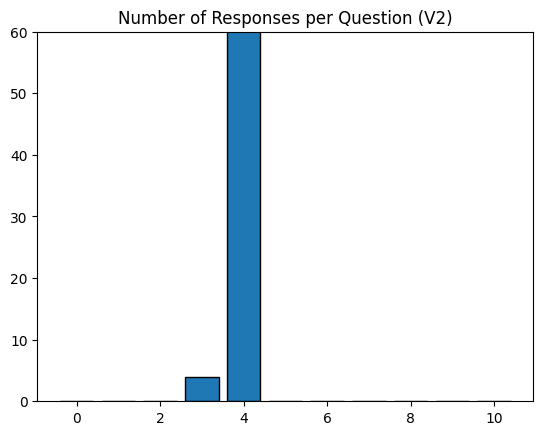

In [29]:
plt.hist(num_responses, bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], edgecolor='black', align='left', rwidth=0.8)
plt.title('Number of Responses per Question (V2)')
plt.ylim([0, 60])
plt.show()

# Qualitative Analysis: 

In [63]:
# df1: nosteer
# df2: persona steer
df1 = nosteer_df
df2 = persona_df
df3 = fewshot_df

k=4
dem_group_to_dem_mapping = {
                              'POLPARTY': ['Democrat', 'Republican'],
                              'SEX': ['Male', 'Female']
                              }

data_path ='/Users/nicolemeister/Desktop/STANFORD/distributions/NYTIMES/NONE_data.json'
with open(data_path, 'r') as json_file:
  # Load JSON data
  data = json.load(json_file)

dem_to_qualtrics_map = {'Democrat': 'Q_NoSteering', 'Republican': 'Q135', 'Male':'Q136', 'Female': 'Q137'}
dem_to_demgroup = {'Democrat': 'POLPARTY', 'Republican': 'POLPARTY', 'Male':'SEX', 'Female': 'SEX'}

tv_across_groups, hv_across_groups, expected_across_groups = [], [], []

list_of_groups = list(dem_to_demgroup.keys())
q_ID_to_TV = {}
q_ID_to_TV_all = {}
for dem in list_of_groups:
  q_ID_to_TV[dem] = {'nosteer_human_values': np.zeros((len(list(data.keys())), 4)), 'persona_human_values': np.zeros((len(list(data.keys())), 4)),'fewshot_human_values': np.zeros((len(list(data.keys())), 4)), 'gt': np.zeros((len(list(data.keys())), 4))}
  for i, qID in enumerate(list(data.keys())):
    qualtricsID = qID_to_qualtricsID[qID]

    # 1. no steer 
    qualtrics_str = 'Q_NoSteering'
    nosteer_cols = []
    nosteer_cols.append(str(qualtricsID)+'_{}_1'.format(qualtrics_str))
    nosteer_cols.append(str(qualtricsID)+'_{}_2'.format(qualtrics_str))
    nosteer_cols.append(str(qualtricsID)+'_{}_3'.format(qualtrics_str))
    nosteer_cols.append(str(qualtricsID)+'_{}_4'.format(qualtrics_str))
    df_cleaned = df1[nosteer_cols].dropna()[:k]

    if len(df_cleaned)>0: 
      expected_results_str = '{}'.format(dem)
      MC_options = list(data[qID][expected_results_str].keys())
      
      nosteer_human_values = np.mean(np.array(df_cleaned, dtype=np.float64), axis=0)[:len(MC_options)] * 0.01
      nosteer_human_results = dict(zip(MC_options, nosteer_human_values))

    # 2. persona steer
    qualtrics_str = dem_to_qualtrics_map[dem]
    persona_cols = []
    persona_cols.append(str(qualtricsID)+'_{}_1'.format(qualtrics_str))
    persona_cols.append(str(qualtricsID)+'_{}_2'.format(qualtrics_str))
    persona_cols.append(str(qualtricsID)+'_{}_3'.format(qualtrics_str))
    persona_cols.append(str(qualtricsID)+'_{}_4'.format(qualtrics_str))

    df_cleaned = df2[persona_cols].dropna()[:k]

    if len(df_cleaned)>0: 
      expected_results_str = '{}'.format(dem)
      MC_options = list(data[qID][expected_results_str].keys())
      
      persona_human_values = np.mean(np.array(df_cleaned, dtype=np.float64), axis=0)[:len(MC_options)] * 0.01
      persona_human_results = dict(zip(MC_options, persona_human_values))


    # 3. fewshot steer
    qualtrics_str = dem_to_qualtrics_map[dem]
    fewshot_cols = []
    fewshot_cols.append(str(qualtricsID)+'_{}_1'.format(qualtrics_str))
    fewshot_cols.append(str(qualtricsID)+'_{}_2'.format(qualtrics_str))
    fewshot_cols.append(str(qualtricsID)+'_{}_3'.format(qualtrics_str))
    fewshot_cols.append(str(qualtricsID)+'_{}_4'.format(qualtrics_str))

    df_cleaned = df3[fewshot_cols].dropna()[:k]

    if len(df_cleaned)>0: 
      expected_results_str = '{}'.format(dem)
      MC_options = list(data[qID][expected_results_str].keys())
      
      fewshot_human_values = np.mean(np.array(df_cleaned, dtype=np.float64), axis=0)[:len(MC_options)] * 0.01
      fewshot_human_results = dict(zip(MC_options, fewshot_human_values))

      gt_results = normalize(np.array(list(data[qID][expected_results_str].values())))

      # print(human_values, gt_results)
      tv_nosteer = calc_total_variation(nosteer_human_values, gt_results)
      tv_persona = calc_total_variation(persona_human_values, gt_results)
      tv_fewshot = calc_total_variation(fewshot_human_values, gt_results)


      q_ID_to_TV[dem]['nosteer_human_values'][i] = nosteer_human_values
      q_ID_to_TV[dem]['persona_human_values'][i] = persona_human_values
      q_ID_to_TV[dem]['fewshot_human_values'][i] = fewshot_human_values
      q_ID_to_TV[dem]['gt'][i] = gt_results
  
  q_ID_to_TV[dem]['nosteer_human_values_avg'] = q_ID_to_TV[dem]['nosteer_human_values'].mean(axis=0)
  q_ID_to_TV[dem]['nosteer_human_values_bs'] = []
  for i in range(4):
    _, bs = compute_one(q_ID_to_TV[dem]['nosteer_human_values'][:, i])
    q_ID_to_TV[dem]['nosteer_human_values_bs'].append(bs)
  
  q_ID_to_TV[dem]['persona_human_values_avg'] = q_ID_to_TV[dem]['persona_human_values'].mean(axis=0)
  q_ID_to_TV[dem]['persona_human_values_bs'] = []
  for i in range(4):
    _, bs = compute_one(q_ID_to_TV[dem]['persona_human_values'][:, i])
    q_ID_to_TV[dem]['persona_human_values_bs'].append(bs)


  q_ID_to_TV[dem]['fewshot_human_values_avg'] = q_ID_to_TV[dem]['fewshot_human_values'].mean(axis=0)
  q_ID_to_TV[dem]['fewshot_human_values_bs'] = []
  for i in range(4):
    _, bs = compute_one(q_ID_to_TV[dem]['fewshot_human_values'][:, i])
    q_ID_to_TV[dem]['fewshot_human_values_bs'].append(bs)

  
  q_ID_to_TV[dem]['gt_avg'] = q_ID_to_TV[dem]['gt'].mean(axis=0)
  q_ID_to_TV[dem]['gt_bs'] = []
  for i in range(4):
    _, bs = compute_one(q_ID_to_TV[dem]['gt'][:, i])
    q_ID_to_TV[dem]['gt_bs'].append(bs)

In [59]:
print(q_ID_to_TV['Democrat']['nosteer_human_values_avg'], q_ID_to_TV['Democrat']['nosteer_human_values_bs'])
print(q_ID_to_TV['Democrat']['persona_human_values_avg'], q_ID_to_TV['Democrat']['persona_human_values_bs'])
print(q_ID_to_TV['Democrat']['fewshot_human_values_avg'], q_ID_to_TV['Democrat']['fewshot_human_values_bs'])
print(q_ID_to_TV['Democrat']['gt_avg'], q_ID_to_TV['Democrat']['gt_bs'])

[0.29950709 0.24697518 0.25257092 0.20094681] [0.011923758865248213, 0.0068841755319148795, 0.008605274822695005, 0.008046143617021273]
[0.20018085 0.23893617 0.29715957 0.2637234 ] [0.013160505319148932, 0.008826994680851047, 0.008831250000000013, 0.012024867021276586]
[0.28029433 0.25680142 0.25958511 0.20331915] [0.010630363475177318, 0.006617287234042563, 0.0076862588652482355, 0.008589273049645352]
[0.32844719 0.28012291 0.27122633 0.12020356] [0.0180178271476564, 0.014511638922086179, 0.01552015638282192, 0.011172314880599492]


In [74]:
q_ID_to_TV['Democrat']['nosteer_human_values'].shape

(235, 4)

In [81]:
# save dictionary as lists first
from collections import defaultdict
q_ID_to_TV_tosave = defaultdict(dict)

for dem in ['Democrat', 'Republican', 'Male', 'Female']:

    q_ID_to_TV_tosave[dem]['nosteer_avg'] = q_ID_to_TV[dem]['nosteer_human_values_avg'].tolist()
    q_ID_to_TV_tosave[dem]['persona_avg'] = q_ID_to_TV[dem]['persona_human_values_avg'].tolist()
    q_ID_to_TV_tosave[dem]['fewshot_avg'] = q_ID_to_TV[dem]['fewshot_human_values_avg'].tolist()
    q_ID_to_TV_tosave[dem]['gt_avg'] = q_ID_to_TV[dem]['gt_avg'].tolist()

    q_ID_to_TV_tosave[dem]['nosteer_bs'] = q_ID_to_TV[dem]['nosteer_human_values_bs']
    q_ID_to_TV_tosave[dem]['persona_bs'] = q_ID_to_TV[dem]['persona_human_values_bs']
    q_ID_to_TV_tosave[dem]['fewshot_bs'] = q_ID_to_TV[dem]['fewshot_human_values_bs']
    q_ID_to_TV_tosave[dem]['gt_bs'] = q_ID_to_TV[dem]['gt_bs']


In [80]:
# Save dictionary as a JSON file
with open('/Users/nicolemeister/Desktop/STANFORD/distributions/data_analysis/data/NYT_q_ID_to_TV.json', 'w') as json_file:
    json.dump(q_ID_to_TV_tosave, json_file)

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:6: UserWarning: l

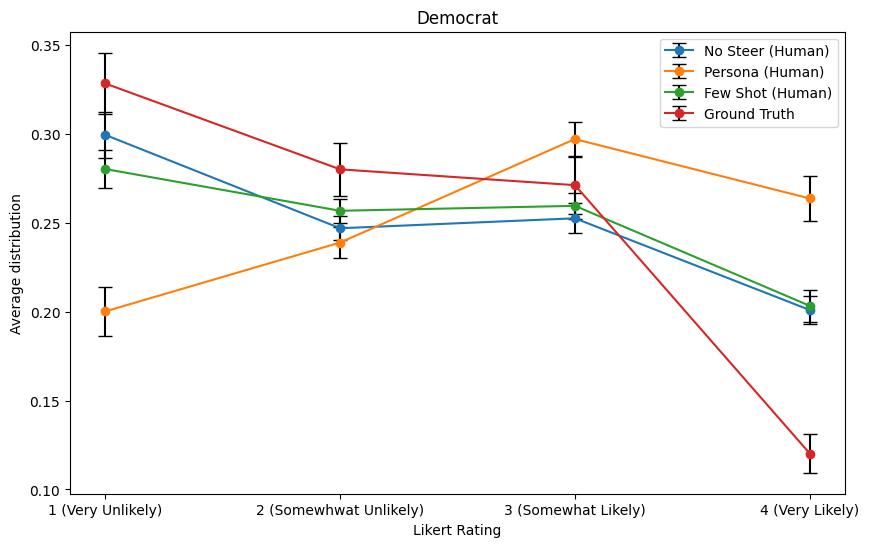

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:6: UserWarning: l

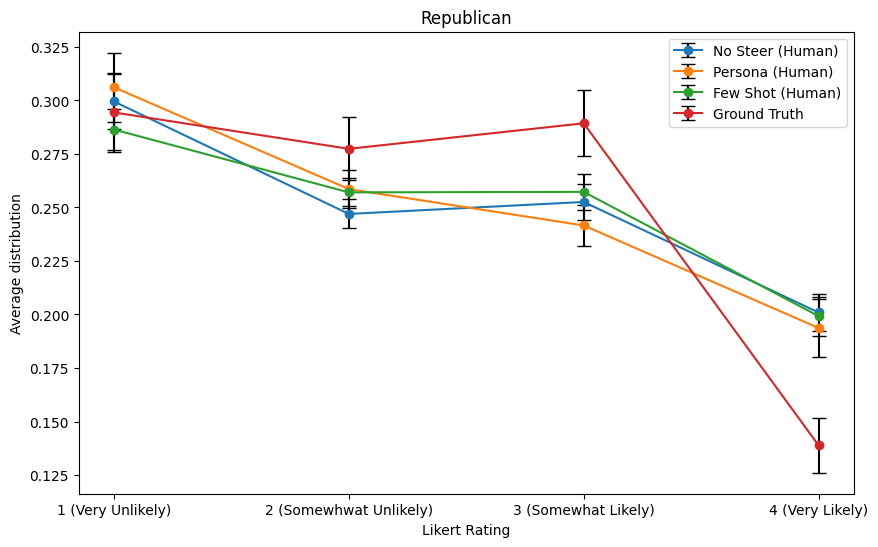

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:6: UserWarning: l

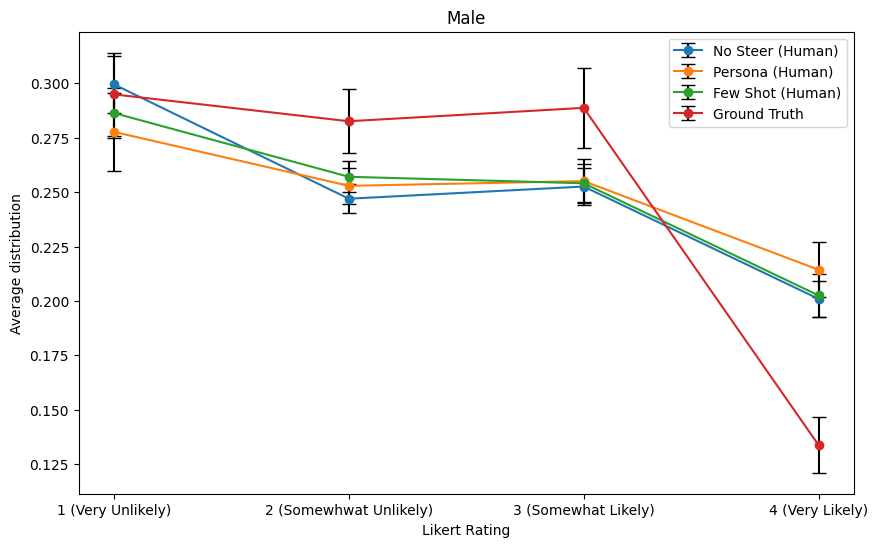

/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
/var/folders/_r/w12mdwc56wb9k_g0q82pk8400000gn/T/ipykernel_29371/695081711.py:6: UserWarning: l

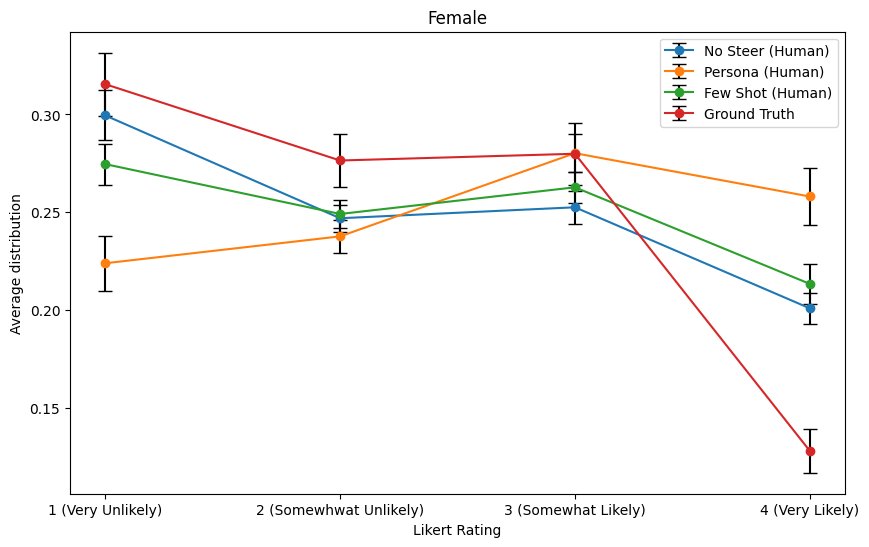

In [67]:
# Creating the line plot with error bars

for dem in list_of_groups:
    plt.figure(figsize=(10, 6))
    labels = ['1 (Very Unlikely)', '2 (Somewhwat Unlikely)', '3 (Somewhat Likely)', '4 (Very Likely)']
    plt.errorbar(labels, q_ID_to_TV[dem]['nosteer_human_values_avg'], yerr=q_ID_to_TV[dem]['nosteer_human_values_bs'], label='No Steer (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
    plt.errorbar(labels, q_ID_to_TV[dem]['persona_human_values_avg'], yerr=q_ID_to_TV[dem]['persona_human_values_bs'], label='Persona (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
    plt.errorbar(labels, q_ID_to_TV[dem]['fewshot_human_values_avg'], yerr=q_ID_to_TV[dem]['fewshot_human_values_bs'], label='Few Shot (Human)', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
    plt.errorbar(labels, q_ID_to_TV[dem]['gt_avg'], yerr=q_ID_to_TV[dem]['gt_bs'], label='Ground Truth', fmt='-o', ecolor='black', capsize=5, linestyle='-', marker='o')
    
    # Adding title and labels
    plt.title(dem)
    plt.xlabel('Likert Rating')
    plt.ylabel('Average distribution')
    plt.legend()
    # Display the chart
    plt.show()


#### Box plot version

In [71]:
q_ID_to_TV[dem]['nosteer_human_values']

array([[0.175     , 0.2325    , 0.285     , 0.3075    ],
       [0.15      , 0.4375    , 0.225     , 0.1875    ],
       [0.3       , 0.1875    , 0.3375    , 0.175     ],
       [0.275     , 0.15      , 0.275     , 0.3       ],
       [0.2       , 0.2625    , 0.3625    , 0.175     ],
       [0.355     , 0.17      , 0.175     , 0.3       ],
       [0.15      , 0.1375    , 0.3       , 0.4125    ],
       [0.25      , 0.25      , 0.325     , 0.175     ],
       [0.2       , 0.2375    , 0.325     , 0.2375    ],
       [0.4625    , 0.225     , 0.175     , 0.1375    ],
       [0.1875    , 0.25      , 0.2875    , 0.275     ],
       [0.4       , 0.2375    , 0.1875    , 0.175     ],
       [0.2625    , 0.2125    , 0.375     , 0.15      ],
       [0.2375    , 0.2625    , 0.2375    , 0.2625    ],
       [0.175     , 0.3125    , 0.3625    , 0.15      ],
       [0.2125    , 0.275     , 0.2875    , 0.225     ],
       [0.25      , 0.275     , 0.2875    , 0.1875    ],
       [0.3125    , 0.2375    ,

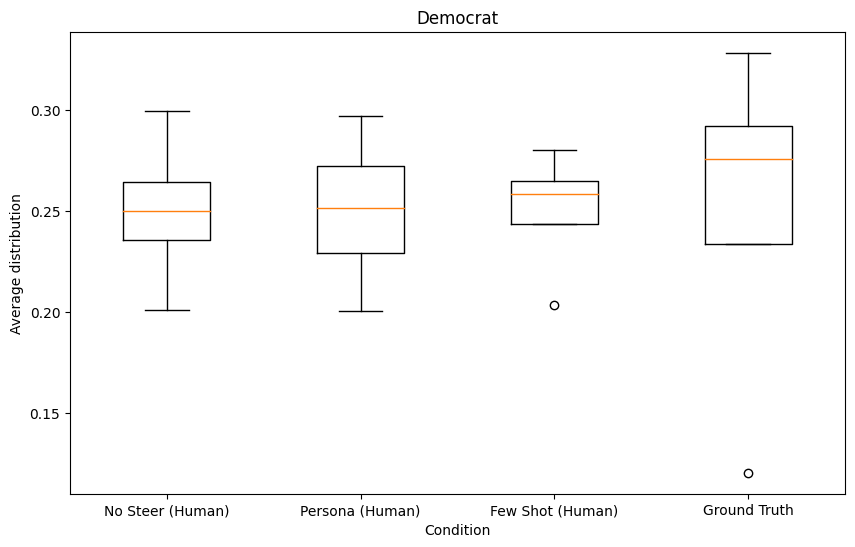

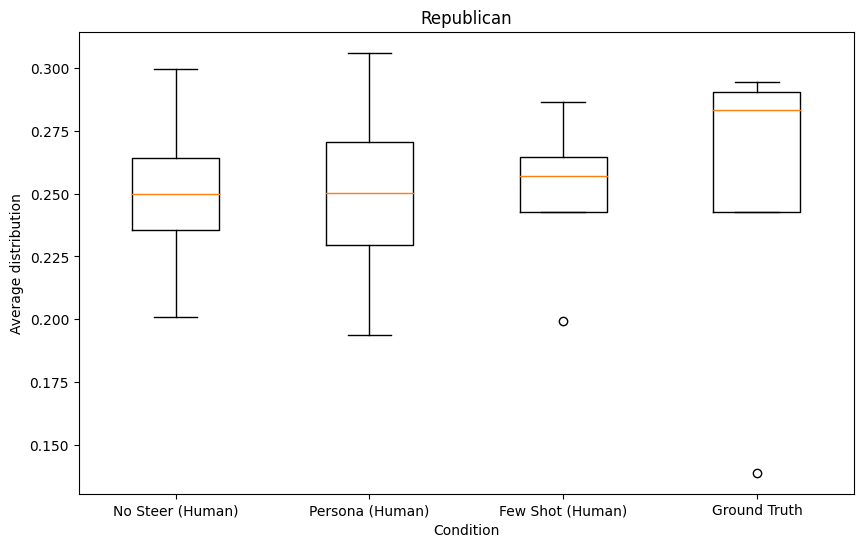

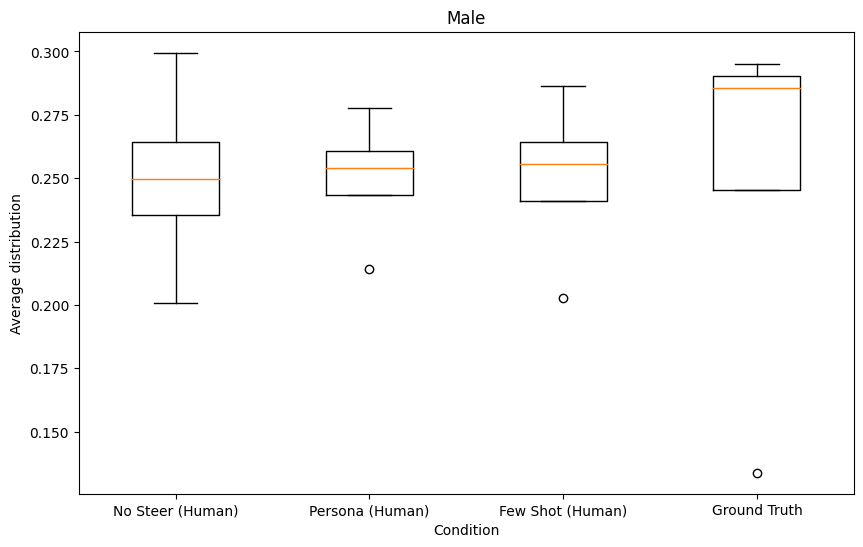

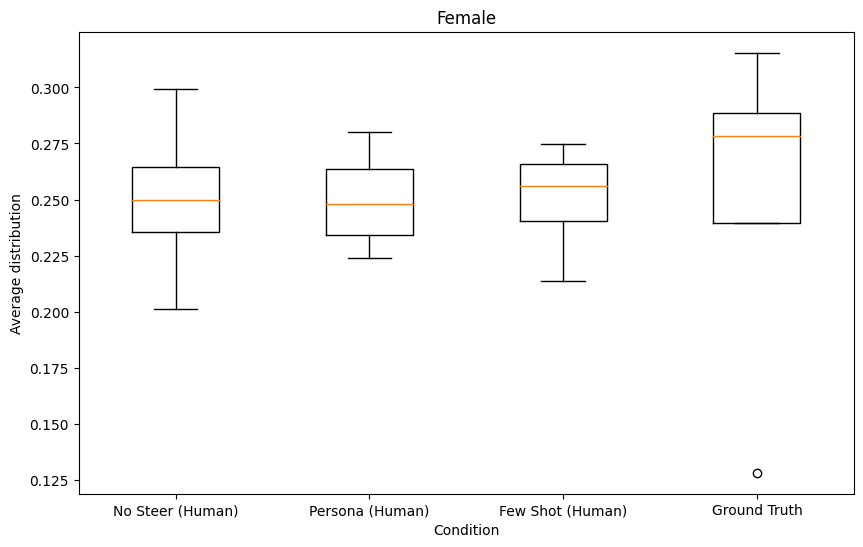

In [68]:
import matplotlib.pyplot as plt

# Assuming q_ID_to_TV and list_of_groups are already defined
for dem in list_of_groups:
    plt.figure(figsize=(10, 6))
    
    # Collect data for the boxplot
    data = [
        q_ID_to_TV[dem]['nosteer_human_values_avg'],
        q_ID_to_TV[dem]['persona_human_values_avg'],
        q_ID_to_TV[dem]['fewshot_human_values_avg'],
        q_ID_to_TV[dem]['gt_avg']
    ]
    
    # Creating the boxplot
    plt.boxplot(data, labels=['No Steer (Human)', 'Persona (Human)',  'Few Shot (Human)', 'Ground Truth'])
    
    # Adding title and labels
    plt.title(dem)
    plt.xlabel('Condition')
    plt.ylabel('Average distribution')
    
    # Display the chart
    plt.show()


Persona Steering

Few Shot Steering

## Human vs models we've evaluated so far

No Steering

Persona Steering

Few Shot Steering

## Quality control (we ask the survey participants to answer the survey question as well, does this align with the opinionQA results)

No Steering

Persona Steering

Few Shot Steering

## Post stratifying and looking at how performance on the task changes with ingroup/outgroup participants

No Steering

Persona Steering

Few Shot Steering